In [1]:
from langchain.chat_models import init_chat_model

model = init_chat_model("google_genai:gemini-3-flash-preview")
res = model.invoke("hii who i am")
print(res.text)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


I don’t actually know your name or personal identity! As an AI, I don’t have access to your personal files, your camera, or your private information unless you choose to share it with me.

In this conversation, you are a person asking me a question, and I am here to help you.

**If you’d like, you can tell me a bit about yourself!** For example:
*   What is your name?
*   What are your hobbies?
*   What are you working on today?

How can I help you today?


## Define Schema

In [3]:
from typing import TypedDict,List

class graph_schema(TypedDict):
    name:str
    message:str

### Create Node fun

In [12]:
def welcome(state:graph_schema)->graph_schema:
    curr_name = state['name']
    curr_message = state['message']

    res = model.invoke(f"My name is {curr_name} and in want to know about {curr_message}")

    state['message'] = res.text

    return state

### create state graph

In [14]:
from langgraph.graph import StateGraph,START,END

state_graph = StateGraph(graph_schema)

state_graph.add_node("welcome",welcome)

state_graph.add_edge(START,"welcome")
state_graph.add_edge("welcome",END)

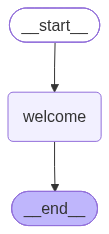

In [16]:
state_graph.compile()